In [3]:
import h5py
import psana
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import  rotate
from scipy.interpolate import interp1d
from scipy.optimize import curve_fit,minimize
from matplotlib.backends.backend_pdf import PdfPages
import multiprocessing
import os
from functools import partial
import time
import sys
import argparse
from datetime import datetime
import tempfile
import XSpect.XSpect_Analysis
import XSpect.XSpect_Controller
import XSpect.XSpect_Visualization
import XSpect.XSpect_Diagnostics as dt
import XSpect.XSpect_PostProcessing

ModuleNotFoundError: No module named 'psana'

Run 74 imported


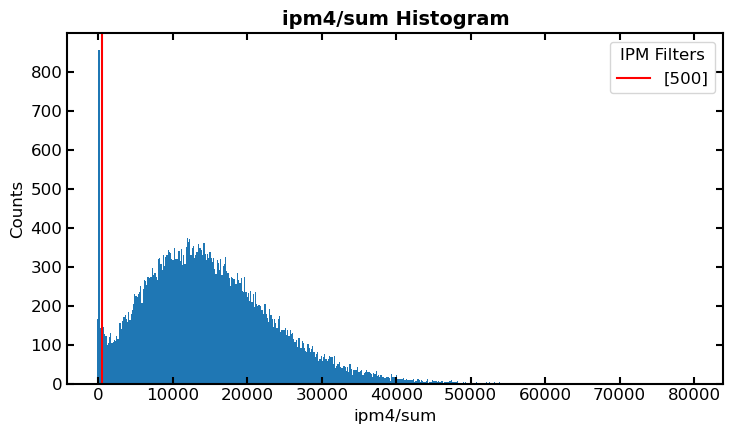

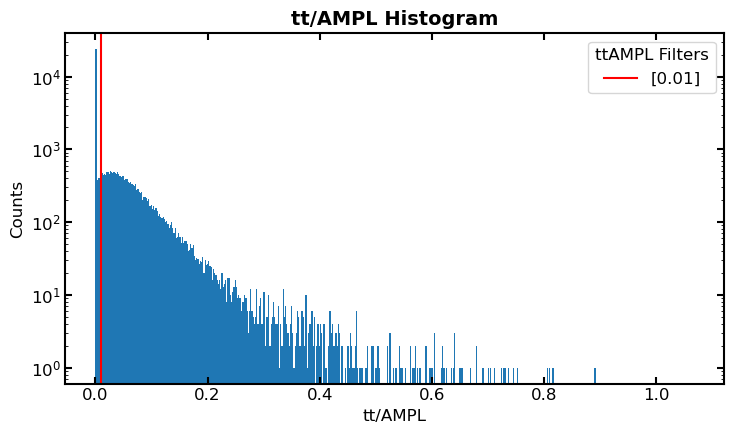

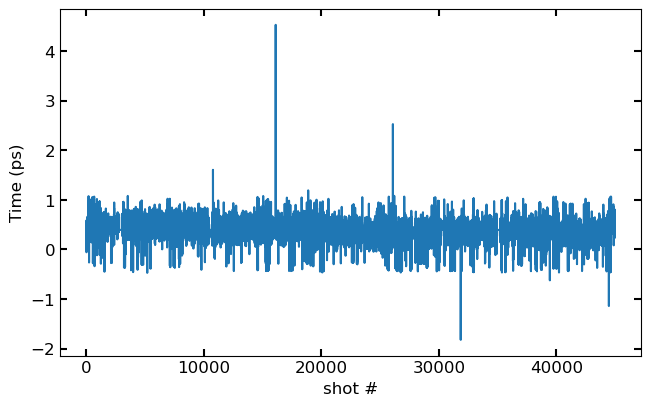

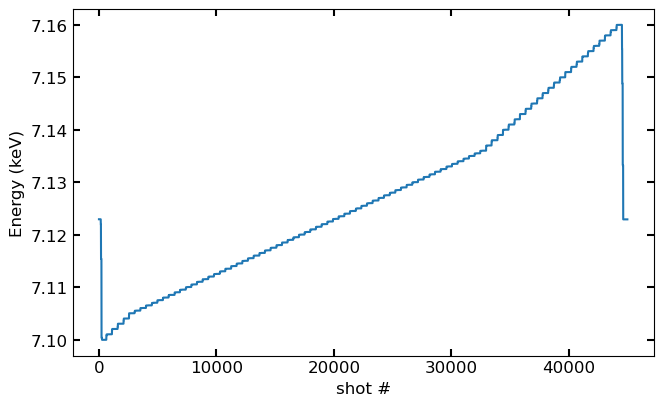

In [3]:
run = 74
exp = 'xcs101237825'
keys=['epicsUser/dccm_E', 'epicsUser/dccm_E_setpoint', 'tt/ttCorr','epics/lxt', 'enc/lasDelay' , 'ipm4/sum','tt/AMPL'] 
names=['ccm','ccm_E_setpoint','time_tool_correction','lxt'  ,'encoder','ipm', 'time_tool_ampl']

# pdf = PdfPages("output.pdf")

d = dt.diagnostics(run, exp, keys, names)

ipm_thres = [500]

d.ipm_histogram(ipm_thres)

# figx = plt.gcf()
# pdf.savefig(figx)

tt_thres = [0.01]

d.ttAMPL_histogram(tt_thres)

# d.droplet_histogram()

nshots = 1000

# adu_thres = [3.5]
# d.adu_histogram(nshots, adu_thres)

# ka_roi_d = [270, 300]
# kb_roi_d = [180, 220]

# d.detector_sum_ROI(ka_roi_d, kb_roi_d)

# ka_roi = [100, 120]
# kb_roi = [15, 55]

# d.xes_ROI(nshots, ka_limits = ka_roi, kb_limits = kb_roi, angle = 0)

# d.xes_ROI(nshots, ka_limits = ka_roi, kb_limits = kb_roi, angle = 1.4)

delay = d.h5[d.datadict['time_tool_correction']][:] + d.h5[d.datadict['lxt']][:]*1e12 + d.h5[d.datadict['encoder']][:]

plt.plot(delay)
plt.ylabel('Time (ps)')
# plt.ylim([0, 5])
plt.xlabel('shot #')
plt.show()

plt.plot(d.h5['epicsUser']['dccm_E'][:])
plt.xlabel('shot #')
plt.ylabel('Energy (keV)')
plt.show()

# pdf.close()

### XANES 1D Energy

In [2]:
start = time.time()

xspect_experiment = XSpect.XSpect_Analysis.spectroscopy_experiment(hutch='xcs',experiment_id=exp,lcls_run=exp[-2:])
xes1=XSpect.XSpect_Controller.XASBatchAnalysis_1D_ccm()
keys=['epicsUser/dccm_E', 'epicsUser/dccm_E_setpoint', 'tt/ttCorr','epics/lxt', 'enc/lasDelay' , 'ipm4/sum','tt/AMPL', 'epix_2/ROI_sum'] 
names=['ccm','ccm_E_setpoint','time_tool_correction','lxt'  ,'encoder','ipm', 'time_tool_ampl', 'epix']

#Here we define the epix detector keys separately as they are imported separately to avoid OOM
# xes1.key_epix=['epix_2/ROI_sum']
# xes1.friendly_name_epix=['epix']

##
xes1.set_key_aliases(keys,names)

xes1.transpose=False
xes1.add_filter('xray','ipm',500)
xes1.add_filter('simultaneous','ipm',500)
xes1.scattering = True

xes1.run_parser(['162-165']) # 1 ns

NameError: name 'time' is not defined

In [121]:
start=time.time()

xes1.primary_analysis_loop(xspect_experiment, verbose = True)

end=time.time()
print('Analysis completed: %.02f s' % (end - start))

Obtained shot properties
HDF5 import of keys completed. Time: 0.08 seconds
Mask: xray has been filtered on ipm by minimum threshold: 500.000
Shots removed: 6015
Mask: simultaneous has been filtered on ipm by minimum threshold: 500.000
Shots removed: 4297
Shots (41879) combined for detector epix on filters: simultaneous and laser into epix_simultaneous_laser
Shots (16753) separated for detector epix on filters: xray and laser into epix_xray_not_laser
Shots (41879) combined for detector ipm on filters: simultaneous and laser into ipm_simultaneous_laser
Shots (16753) separated for detector ipm on filters: xray and laser into ipm_xray_not_laser
Shots (41879) combined for detector ccm on filters: simultaneous and laser into ccm_simultaneous_laser
Shots (16753) separated for detector ccm on filters: xray and laser into ccm_xray_not_laser
Generated ccm bins from 7.100500 to 7.160250 in 136 steps.
Shots (41879) combined for detector ccm_bin_indices on filters: simultaneous and laser into ccm_b

In [122]:
run_count = 0
for ii, run in enumerate(xes1.analyzed_runs):
    print(ii)
    print(run.ccm_bins.shape)
    print(run.epix_simultaneous_laser_energy_binned.shape)
    print(run.epix_xray_not_laser_energy_binned.shape)
    run_count+=1

0
(136,)
(136,)
(136,)
1
(136,)
(136,)
(136,)
2
(136,)
(136,)
(136,)


/lscratch/prakash/tmp/ipykernel_2847310/1631014695.py:8: RuntimeWarning: invalid value encountered in divide
  xas_loff_norm = run.epix_xray_not_laser_energy_binned/run.ipm_xray_not_laser_energy_binned
/lscratch/prakash/tmp/ipykernel_2847310/1631014695.py:9: RuntimeWarning: invalid value encountered in divide
  xas_lon_norm = run.epix_simultaneous_laser_energy_binned/run.ipm_simultaneous_laser_energy_binned


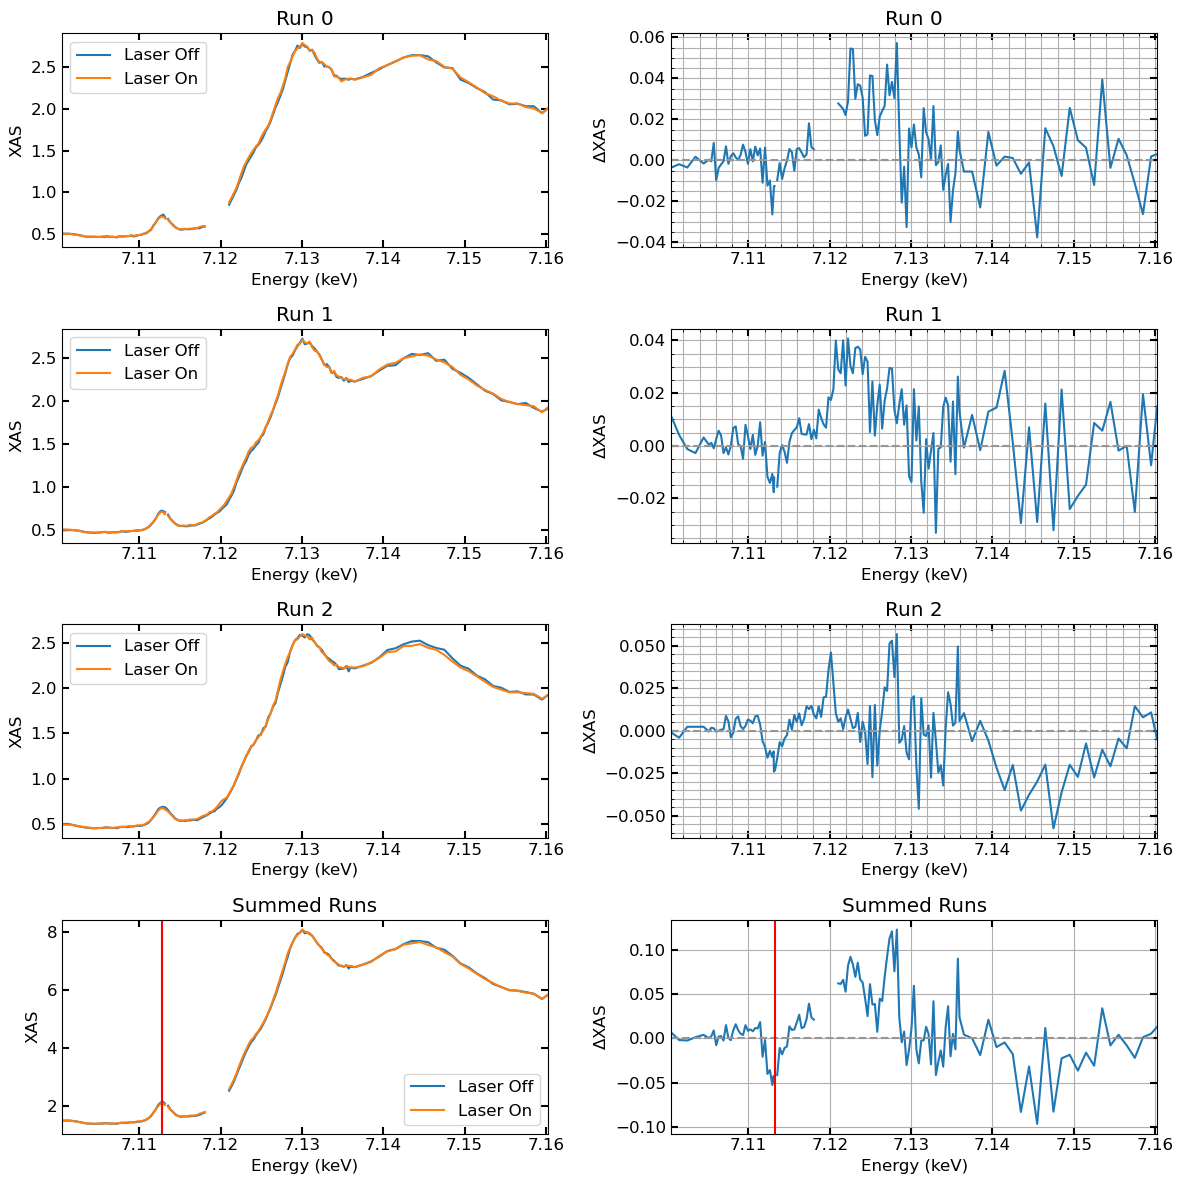

In [123]:
fig, ax = plt.subplots(figsize = (12,12), nrows = run_count+1, ncols = 2)
# fig, ax = plt.subplots(figsize = (9,8), nrows = 1, ncols = 2)

xas_loff_sum = np.zeros_like(xes1.analyzed_runs[0].epix_xray_not_laser_energy_binned)
xas_lon_sum = np.zeros_like(xes1.analyzed_runs[0].epix_simultaneous_laser_energy_binned)

for ii, run in enumerate(xes1.analyzed_runs):
    xas_loff_norm = run.epix_xray_not_laser_energy_binned/run.ipm_xray_not_laser_energy_binned
    xas_lon_norm = run.epix_simultaneous_laser_energy_binned/run.ipm_simultaneous_laser_energy_binned
    xas_diff_norm = xas_lon_norm - xas_loff_norm

    plt_indx0 = (ii,0)
    plt_indx1 = (ii,1)

    ax[plt_indx0].plot(run.ccm_bins, xas_loff_norm, label = 'Laser Off')
    ax[plt_indx0].plot(run.ccm_bins, xas_lon_norm, label = 'Laser On')
    ax[plt_indx0].set_xlim([np.min(run.ccm_bins), np.max(run.ccm_bins)])
    ax[plt_indx0].set_xlabel('Energy (keV)')
    ax[plt_indx0].set_ylabel('XAS')
    ax[plt_indx0].legend()
    ax[plt_indx0].set_title('Run %i' % ii)
    # ax[plt_indx0].grid()

    ax[plt_indx1].plot(run.ccm_bins, xas_diff_norm, label = 'Difference')
    ax[plt_indx1].axhline(0, color = np.array([150,150,150])/255, linestyle = '--')
    ax[plt_indx1].set_xlim([np.min(run.ccm_bins), np.max(run.ccm_bins)])
    ax[plt_indx1].set_xlabel('Energy (keV)')
    ax[plt_indx1].set_ylabel(r'$\Delta$XAS')
    ax[plt_indx1].set_title('Run %i' % ii)
    ax[plt_indx1].minorticks_on()
    # ax[plt_indx1].grid()
    ax[plt_indx1].grid(which = 'both')
    
    
    xas_loff_sum += xas_loff_norm
    xas_lon_sum += xas_lon_norm

xas_diff_sum = xas_lon_sum - xas_loff_sum

plt_indx0_sum = (ii+1,0)
plt_indx1_sum = (ii+1,1)

ax[plt_indx0_sum].plot(run.ccm_bins, xas_loff_sum, label = 'Laser Off')
ax[plt_indx0_sum].plot(run.ccm_bins, xas_lon_sum, label = 'Laser On')
ax[plt_indx0_sum].set_xlim([np.min(run.ccm_bins), np.max(run.ccm_bins)])
ax[plt_indx0_sum].set_xlabel('Energy (keV)')
ax[plt_indx0_sum].set_ylabel('XAS')
ax[plt_indx0_sum].legend()
ax[plt_indx0_sum].set_title('Summed Runs')
ax[plt_indx0_sum].axvline(7.1128, color = 'r')

ax[plt_indx1_sum].plot(run.ccm_bins, xas_diff_sum, label = 'Difference')
ax[plt_indx1_sum].axhline(0, color = np.array([150,150,150])/255, linestyle = '--')
ax[plt_indx1_sum].set_xlim([np.min(run.ccm_bins), np.max(run.ccm_bins)])
ax[plt_indx1_sum].set_xlabel('Energy (keV)')
ax[plt_indx1_sum].set_ylabel(r'$\Delta$XAS')
ax[plt_indx1_sum].set_title('Summed Runs')
ax[plt_indx1_sum].axvline(7.1133, color = 'r')

plt.grid()
plt.tight_layout()

/lscratch/prakash/tmp/ipykernel_2847310/339455510.py:8: RuntimeWarning: invalid value encountered in divide
  xas_loff_norm = run.epix_xray_not_laser_energy_binned/run.ipm_xray_not_laser_energy_binned
/lscratch/prakash/tmp/ipykernel_2847310/339455510.py:9: RuntimeWarning: invalid value encountered in divide
  xas_lon_norm  = run.epix_simultaneous_laser_energy_binned/run.ipm_simultaneous_laser_energy_binned


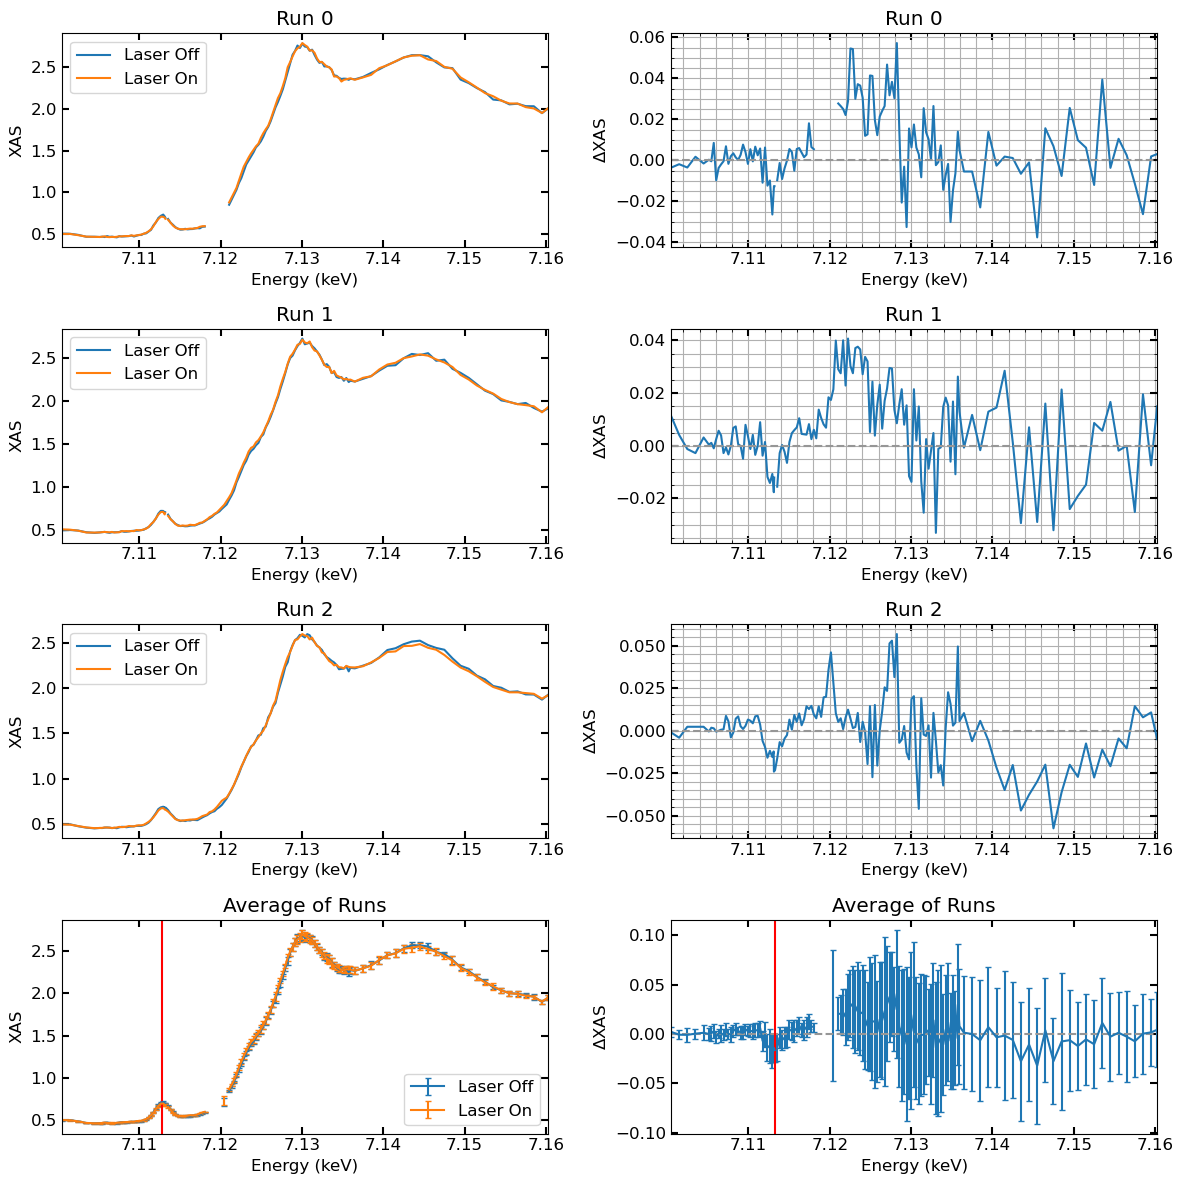

In [124]:
fig, ax = plt.subplots(figsize = (12,12), nrows = run_count+1, ncols = 2)

xas_loff_all = []
xas_lon_all  = []

for ii, run in enumerate(xes1.analyzed_runs):

    xas_loff_norm = run.epix_xray_not_laser_energy_binned/run.ipm_xray_not_laser_energy_binned
    xas_lon_norm  = run.epix_simultaneous_laser_energy_binned/run.ipm_simultaneous_laser_energy_binned
    xas_diff_norm = xas_lon_norm - xas_loff_norm

    xas_loff_all.append(xas_loff_norm)
    xas_lon_all.append(xas_lon_norm)

    plt_indx0 = (ii,0)
    plt_indx1 = (ii,1)

    ax[plt_indx0].plot(run.ccm_bins, xas_loff_norm, label = 'Laser Off')
    ax[plt_indx0].plot(run.ccm_bins, xas_lon_norm, label = 'Laser On')
    ax[plt_indx0].set_xlim([np.min(run.ccm_bins), np.max(run.ccm_bins)])
    ax[plt_indx0].set_xlabel('Energy (keV)')
    ax[plt_indx0].set_ylabel('XAS')
    ax[plt_indx0].legend()
    ax[plt_indx0].set_title('Run %i' % ii)

    ax[plt_indx1].plot(run.ccm_bins, xas_diff_norm, label = 'Difference')
    ax[plt_indx1].axhline(0, color = np.array([150,150,150])/255, linestyle = '--')
    ax[plt_indx1].set_xlim([np.min(run.ccm_bins), np.max(run.ccm_bins)])
    ax[plt_indx1].set_xlabel('Energy (keV)')
    ax[plt_indx1].set_ylabel(r'$\Delta$XAS')
    ax[plt_indx1].set_title('Run %i' % ii)
    ax[plt_indx1].minorticks_on()
    ax[plt_indx1].grid(which = 'both')


# ===== Compute mean and SEM =====
xas_loff_all = np.array(xas_loff_all)
xas_lon_all  = np.array(xas_lon_all)

N = xas_loff_all.shape[0]
energy_axis = xes1.analyzed_runs[0].ccm_bins

xas_loff_mean = np.mean(xas_loff_all, axis=0)
xas_lon_mean  = np.mean(xas_lon_all, axis=0)

xas_loff_sem = np.std(xas_loff_all, axis=0, ddof=1)/np.sqrt(N)
xas_lon_sem  = np.std(xas_lon_all, axis=0, ddof=1)/np.sqrt(N)

xas_diff_mean = xas_lon_mean - xas_loff_mean
xas_diff_sem  = np.sqrt(xas_loff_sem**2 + xas_lon_sem**2)


# ===== Final row with error bars =====
plt_indx0_sum = (ii+1,0)
plt_indx1_sum = (ii+1,1)

ax[plt_indx0_sum].errorbar(energy_axis, xas_loff_mean,
                           yerr=xas_loff_sem,
                           label='Laser Off',
                           capsize=2)

ax[plt_indx0_sum].errorbar(energy_axis, xas_lon_mean,
                           yerr=xas_lon_sem,
                           label='Laser On',
                           capsize=2)

ax[plt_indx0_sum].set_xlim([np.min(energy_axis), np.max(energy_axis)])
ax[plt_indx0_sum].set_xlabel('Energy (keV)')
ax[plt_indx0_sum].set_ylabel('XAS')
ax[plt_indx0_sum].legend()
ax[plt_indx0_sum].set_title('Average of Runs')
ax[plt_indx0_sum].axvline(7.1128, color = 'r')


ax[plt_indx1_sum].errorbar(energy_axis, xas_diff_mean,
                           yerr=xas_diff_sem,
                           label='Difference',
                           capsize=2)

ax[plt_indx1_sum].axhline(0, color = np.array([150,150,150])/255, linestyle = '--')
ax[plt_indx1_sum].set_xlim([np.min(energy_axis), np.max(energy_axis)])
ax[plt_indx1_sum].set_xlabel('Energy (keV)')
ax[plt_indx1_sum].set_ylabel(r'$\Delta$XAS')
ax[plt_indx1_sum].set_title('Average of Runs')
ax[plt_indx1_sum].axvline(7.1133, color = 'r')

plt.tight_layout()
plt.show()


/lscratch/prakash/tmp/ipykernel_2847310/2060520619.py:8: RuntimeWarning: invalid value encountered in divide
  xas_loff_norm = run.epix_xray_not_laser_energy_binned/run.ipm_xray_not_laser_energy_binned
/lscratch/prakash/tmp/ipykernel_2847310/2060520619.py:9: RuntimeWarning: invalid value encountered in divide
  xas_lon_norm  = run.epix_simultaneous_laser_energy_binned/run.ipm_simultaneous_laser_energy_binned


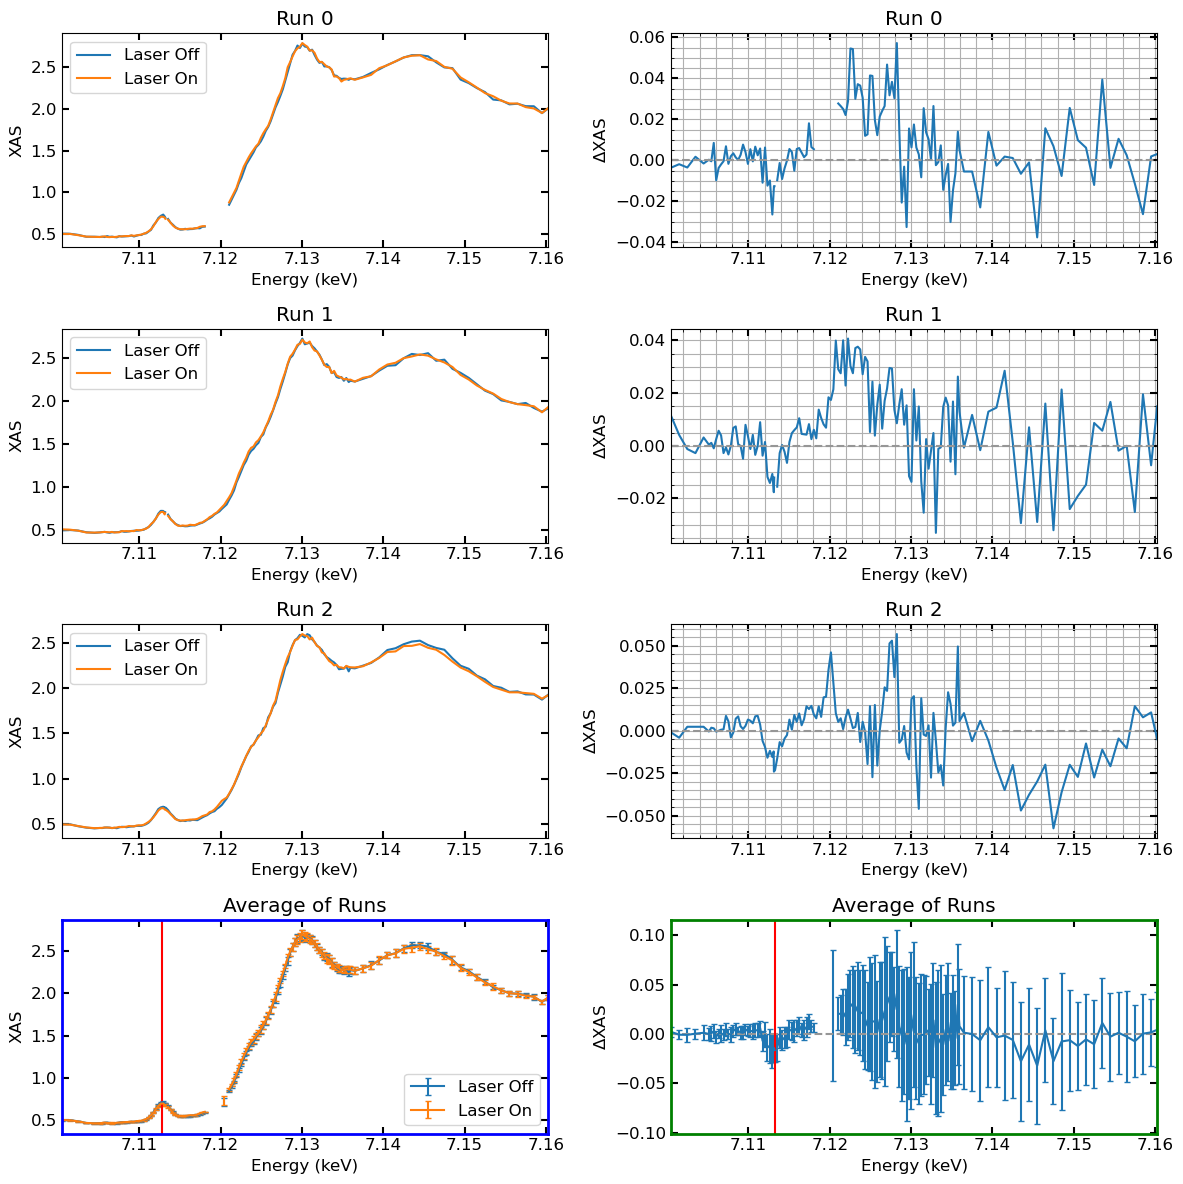

In [125]:
fig, ax = plt.subplots(figsize = (12,12), nrows = run_count+1, ncols = 2)

xas_loff_all = []
xas_lon_all  = []

for ii, run in enumerate(xes1.analyzed_runs):

    xas_loff_norm = run.epix_xray_not_laser_energy_binned/run.ipm_xray_not_laser_energy_binned
    xas_lon_norm  = run.epix_simultaneous_laser_energy_binned/run.ipm_simultaneous_laser_energy_binned
    xas_diff_norm = xas_lon_norm - xas_loff_norm

    xas_loff_all.append(xas_loff_norm)
    xas_lon_all.append(xas_lon_norm)

    plt_indx0 = (ii,0)
    plt_indx1 = (ii,1)

    ax[plt_indx0].plot(run.ccm_bins, xas_loff_norm, label = 'Laser Off')
    ax[plt_indx0].plot(run.ccm_bins, xas_lon_norm, label = 'Laser On')
    ax[plt_indx0].set_xlim([np.min(run.ccm_bins), np.max(run.ccm_bins)])
    ax[plt_indx0].set_xlabel('Energy (keV)')
    ax[plt_indx0].set_ylabel('XAS')
    ax[plt_indx0].legend()
    ax[plt_indx0].set_title('Run %i' % ii)

    ax[plt_indx1].plot(run.ccm_bins, xas_diff_norm, label = 'Difference')
    ax[plt_indx1].axhline(0, color = np.array([150,150,150])/255, linestyle = '--')
    ax[plt_indx1].set_xlim([np.min(run.ccm_bins), np.max(run.ccm_bins)])
    ax[plt_indx1].set_xlabel('Energy (keV)')
    ax[plt_indx1].set_ylabel(r'$\Delta$XAS')
    ax[plt_indx1].set_title('Run %i' % ii)
    ax[plt_indx1].minorticks_on()
    ax[plt_indx1].grid(which = 'both')


# ===== Compute mean and SEM =====
xas_loff_all = np.array(xas_loff_all)
xas_lon_all  = np.array(xas_lon_all)

N = xas_loff_all.shape[0]
energy_axis = xes1.analyzed_runs[0].ccm_bins

xas_loff_mean = np.mean(xas_loff_all, axis=0)
xas_lon_mean  = np.mean(xas_lon_all, axis=0)

xas_loff_sem = np.std(xas_loff_all, axis=0, ddof=1)/np.sqrt(N)
xas_lon_sem  = np.std(xas_lon_all, axis=0, ddof=1)/np.sqrt(N)

xas_diff_mean = xas_lon_mean - xas_loff_mean
xas_diff_sem  = np.sqrt(xas_loff_sem**2 + xas_lon_sem**2)


# ===== Final row with error bars =====
plt_indx0_sum = (ii+1,0)
plt_indx1_sum = (ii+1,1)

ax[plt_indx0_sum].errorbar(energy_axis, xas_loff_mean,
                           yerr=xas_loff_sem,
                           label='Laser Off',
                           capsize=2)

ax[plt_indx0_sum].errorbar(energy_axis, xas_lon_mean,
                           yerr=xas_lon_sem,
                           label='Laser On',
                           capsize=2)

ax[plt_indx0_sum].set_xlim([np.min(energy_axis), np.max(energy_axis)])
ax[plt_indx0_sum].set_xlabel('Energy (keV)')
ax[plt_indx0_sum].set_ylabel('XAS')
ax[plt_indx0_sum].legend()
ax[plt_indx0_sum].set_title('Average of Runs')
ax[plt_indx0_sum].axvline(7.1128, color = 'r')


ax[plt_indx1_sum].errorbar(energy_axis, xas_diff_mean,
                           yerr=xas_diff_sem,
                           label='Difference',
                           capsize=2)

ax[plt_indx1_sum].axhline(0, color = np.array([150,150,150])/255, linestyle = '--')
ax[plt_indx1_sum].set_xlim([np.min(energy_axis), np.max(energy_axis)])
ax[plt_indx1_sum].set_xlabel('Energy (keV)')
ax[plt_indx1_sum].set_ylabel(r'$\Delta$XAS')
ax[plt_indx1_sum].set_title('Average of Runs')
ax[plt_indx1_sum].axvline(7.1133, color = 'r')


# ===== Add coloured borders to final row =====
for spine in ax[plt_indx0_sum].spines.values():
    spine.set_edgecolor('blue')
    spine.set_linewidth(2)

for spine in ax[plt_indx1_sum].spines.values():
    spine.set_edgecolor('green')
    spine.set_linewidth(2)



plt.tight_layout()
plt.show()


/lscratch/prakash/tmp/ipykernel_2847310/239461881.py:8: RuntimeWarning: invalid value encountered in divide
  xas_loff_norm = run.epix_xray_not_laser_energy_binned/run.ipm_xray_not_laser_energy_binned
/lscratch/prakash/tmp/ipykernel_2847310/239461881.py:9: RuntimeWarning: invalid value encountered in divide
  xas_lon_norm  = run.epix_simultaneous_laser_energy_binned/run.ipm_simultaneous_laser_energy_binned


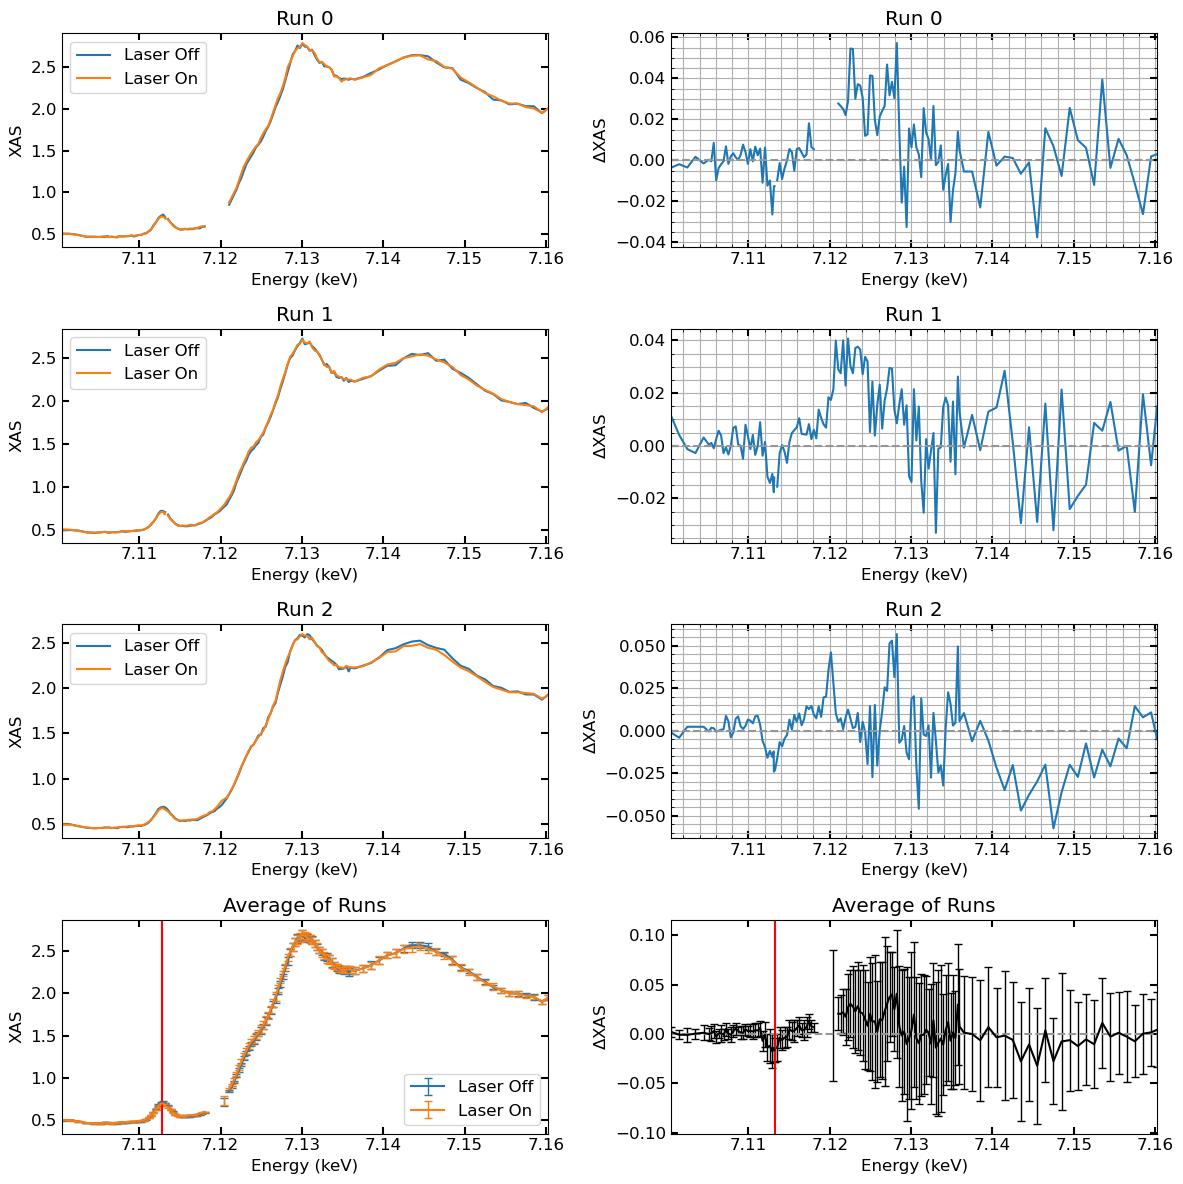

In [126]:
fig, ax = plt.subplots(figsize = (12,12), nrows = run_count+1, ncols = 2)

xas_loff_all = []
xas_lon_all  = []

for ii, run in enumerate(xes1.analyzed_runs):

    xas_loff_norm = run.epix_xray_not_laser_energy_binned/run.ipm_xray_not_laser_energy_binned
    xas_lon_norm  = run.epix_simultaneous_laser_energy_binned/run.ipm_simultaneous_laser_energy_binned
    xas_diff_norm = xas_lon_norm - xas_loff_norm

    xas_loff_all.append(xas_loff_norm)
    xas_lon_all.append(xas_lon_norm)

    plt_indx0 = (ii,0)
    plt_indx1 = (ii,1)

    ax[plt_indx0].plot(run.ccm_bins, xas_loff_norm, label='Laser Off')
    ax[plt_indx0].plot(run.ccm_bins, xas_lon_norm, label='Laser On')
    ax[plt_indx0].set_xlim([np.min(run.ccm_bins), np.max(run.ccm_bins)])
    ax[plt_indx0].set_xlabel('Energy (keV)')
    ax[plt_indx0].set_ylabel('XAS')
    ax[plt_indx0].legend()
    ax[plt_indx0].set_title('Run %i' % ii)

    ax[plt_indx1].plot(run.ccm_bins, xas_diff_norm, label='Difference')
    ax[plt_indx1].axhline(0, color=np.array([150,150,150])/255, linestyle='--')
    ax[plt_indx1].set_xlim([np.min(run.ccm_bins), np.max(run.ccm_bins)])
    ax[plt_indx1].set_xlabel('Energy (keV)')
    ax[plt_indx1].set_ylabel(r'$\Delta$XAS')
    ax[plt_indx1].set_title('Run %i' % ii)
    ax[plt_indx1].minorticks_on()
    ax[plt_indx1].grid(which='both')


# ===== Compute mean and SEM =====
xas_loff_all = np.array(xas_loff_all)
xas_lon_all  = np.array(xas_lon_all)

N = xas_loff_all.shape[0]
energy_axis = xes1.analyzed_runs[0].ccm_bins

xas_loff_mean = np.mean(xas_loff_all, axis=0)
xas_lon_mean  = np.mean(xas_lon_all, axis=0)

xas_loff_sem = np.std(xas_loff_all, axis=0, ddof=1)/np.sqrt(N)
xas_lon_sem  = np.std(xas_lon_all, axis=0, ddof=1)/np.sqrt(N)

xas_diff_mean = xas_lon_mean - xas_loff_mean
xas_diff_sem  = np.sqrt(xas_loff_sem**2 + xas_lon_sem**2)


# ===== Final row with COLOURED error bars =====
plt_indx0_sum = (ii+1,0)
plt_indx1_sum = (ii+1,1)

# Laser Off (blue)
ax[plt_indx0_sum].errorbar(energy_axis, xas_loff_mean,
                           yerr=xas_loff_sem,
                           fmt='-',
                           color='tab:blue',
                           ecolor='tab:blue',
                           elinewidth=1,
                           capsize=3,
                           label='Laser Off')

# Laser On (orange)
ax[plt_indx0_sum].errorbar(energy_axis, xas_lon_mean,
                           yerr=xas_lon_sem,
                           fmt='-',
                           color='tab:orange',
                           ecolor='tab:orange',
                           elinewidth=1,
                           capsize=3,
                           label='Laser On')

ax[plt_indx0_sum].set_xlim([np.min(energy_axis), np.max(energy_axis)])
ax[plt_indx0_sum].set_xlabel('Energy (keV)')
ax[plt_indx0_sum].set_ylabel('XAS')
ax[plt_indx0_sum].legend()
ax[plt_indx0_sum].set_title('Average of Runs')
ax[plt_indx0_sum].axvline(7.1128, color='r')


# Difference (black)
ax[plt_indx1_sum].errorbar(energy_axis, xas_diff_mean,
                           yerr=xas_diff_sem,
                           fmt='-',
                           color='k',
                           ecolor='k',
                           elinewidth=1,
                           capsize=3,
                           label='Difference')

ax[plt_indx1_sum].axhline(0, color=np.array([150,150,150])/255, linestyle='--')
ax[plt_indx1_sum].set_xlim([np.min(energy_axis), np.max(energy_axis)])
ax[plt_indx1_sum].set_xlabel('Energy (keV)')
ax[plt_indx1_sum].set_ylabel(r'$\Delta$XAS')
ax[plt_indx1_sum].set_title('Average of Runs')
ax[plt_indx1_sum].axvline(7.1133, color='r')

plt.tight_layout()
plt.show()


# ===== Save final averaged data to TXT =====
output_data = np.column_stack([
    energy_axis,
    xas_loff_mean,
    xas_loff_sem,
    xas_lon_mean,
    xas_lon_sem,
    xas_diff_mean,
    xas_diff_sem
])

np.savetxt(
    "xas_average_with_errors.txt",
    output_data,
    header="Energy_keV  LaserOff_mean  LaserOff_SEM  LaserOn_mean  LaserOn_SEM  Diff_mean  Diff_SEM"
)
